<a href="https://colab.research.google.com/github/Joyunho11/20230580-/blob/main/20230580%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  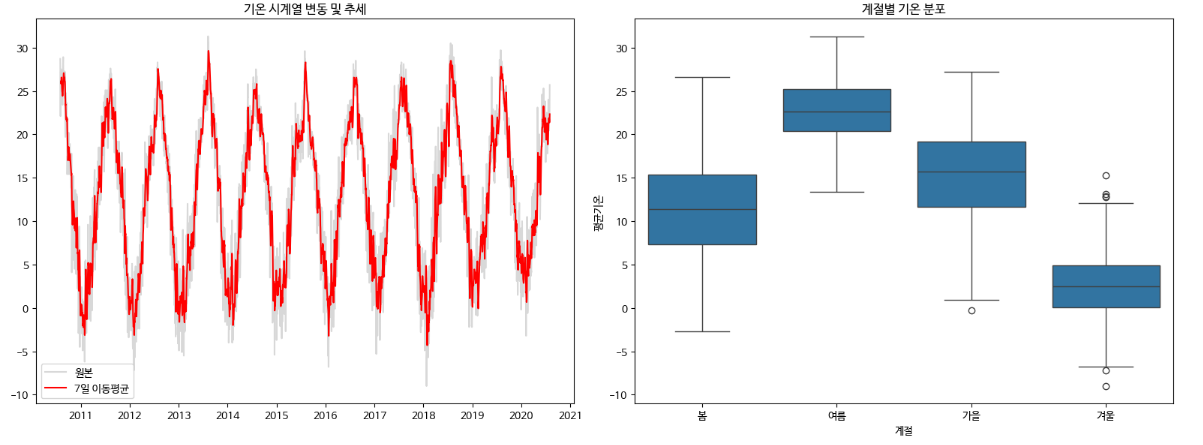

  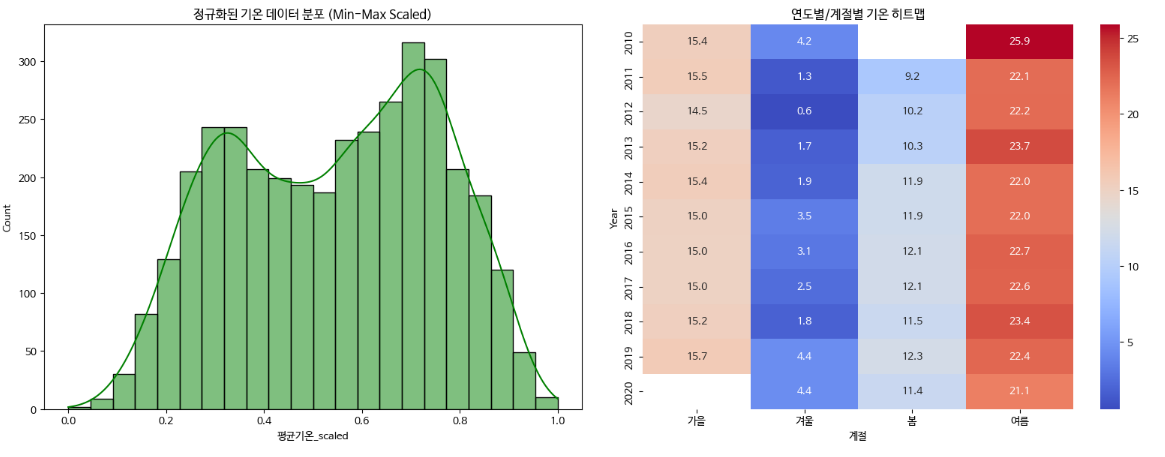



한글 폰트 설정 및 Matplotlib 연동 성공


    count       mean       std   min     25%   50%   75%   max
계절                                                            
가을  910.0  15.201099  5.149311  -0.3  11.625  15.7  19.2  27.2
겨울  903.0   2.506866  3.637645  -9.0   0.100   2.5   4.9  15.3
봄   920.0  11.295543  5.582907  -2.7   7.300  11.4  15.4  26.6
여름  920.0  22.596630  3.355625  13.4  20.375  22.6  25.2  31.3 


계절           가을        겨울          봄         여름
연도                                             
2010  15.368132  4.180645        NaN  25.916129
2011  15.527473  1.286667   9.156522  22.126087
2012  14.460440  0.556044  10.239130  22.220652
2013  15.229670  1.744444  10.323913  23.668478
2014  15.418681  1.850000  11.905435  21.991304
2015  15.045055  3.452222  11.913043  22.048913
2016  15.018681  3.090110  12.088043  22.685870
2017  15.002198  2.461111  12.141304  22.629348
2018  15.223077  1.828889  11.458696  23.435870
2019  15.717582  4.438889  12.315217  22.417391
2020        N

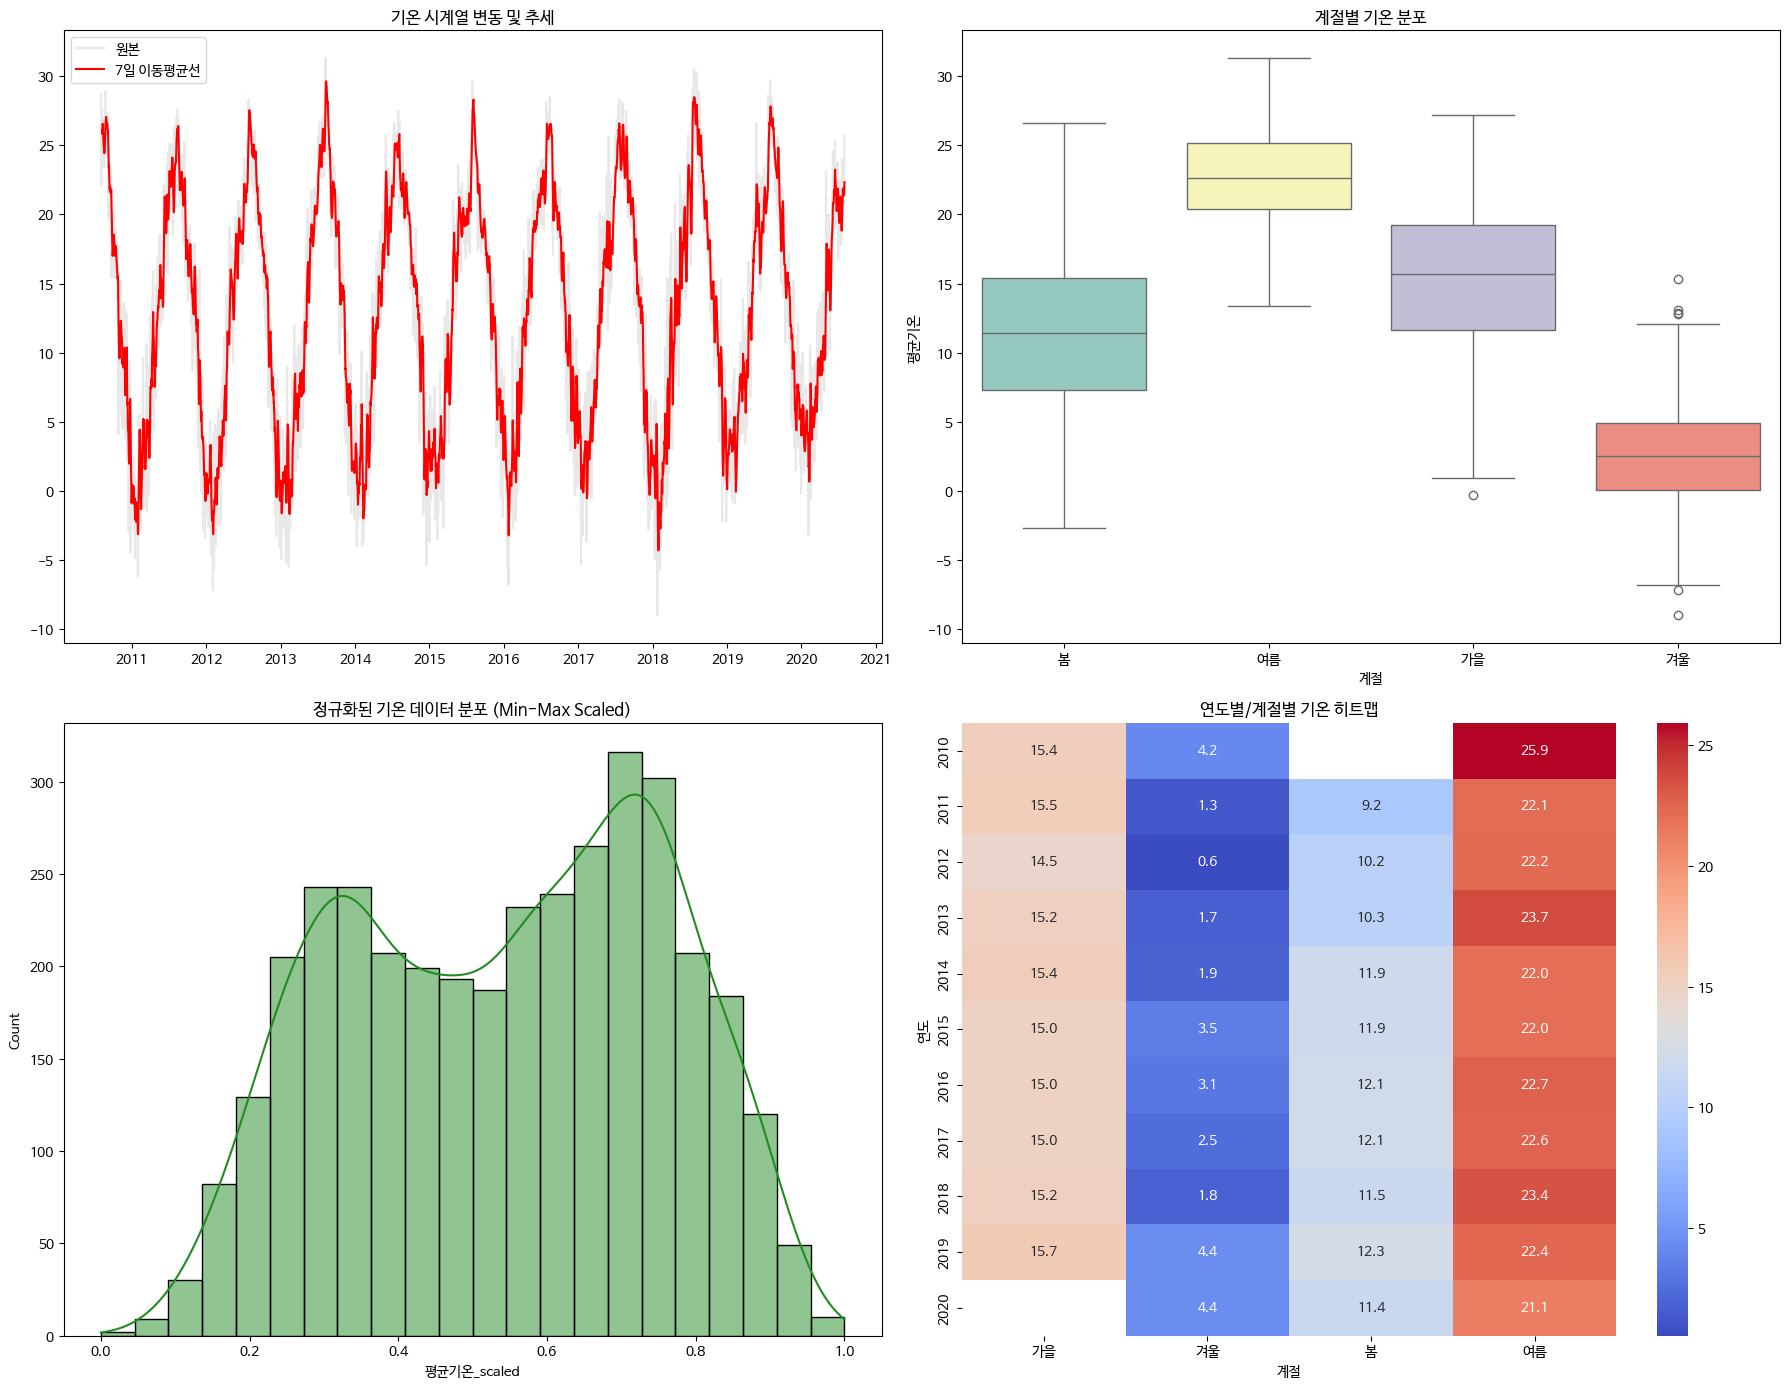

데이터 가공이 완료되었습니다!!


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import matplotlib.font_manager as fm
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#==========================================
# 1. 한글 폰트 설정
#==========================================
def setup_korean_font():
    """한글 폰트 설정 및 Matplotlib 연동"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("한글 폰트 설정 및 Matplotlib 연동 성공\n\n")

setup_korean_font()

# ==========================================
# 2. 독립 함수 설계
# ==========================================

def load_data(url):
    """[데이터 소스] URL 로드 및 시계열 인덱스 설정"""
    try:
        df = pd.read_csv(url, encoding='cp949')
    except:
        df = pd.read_csv(url)

    # [시계열 핸들링] 날짜 변환 및 인덱스 설정 완료
    df['일시'] = pd.to_datetime(df['일시'])
    df = df.set_index('일시')
    return df

def scale_data(df, column='평균기온'):
    """[데이터 정규화] Min-Max Scaling (0~1)"""
    scaler = MinMaxScaler()
    df[f'{column}_scaled'] = scaler.fit_transform(df[[column]])
    return df

def generate_features(df, column='평균기온'):
    """[시계열 핸들링] 7일 이동평균선 및 계절 생성"""
    df['7일 이동평균선'] = df[column].rolling(window=7).mean()
    df['연도'] = df.index.year
    df['월'] = df.index.month

    def get_season(month):
        if month in [3, 4, 5]: return '봄'
        elif month in [6, 7, 8]: return '여름'
        elif month in [9, 10, 11]: return '가을'
        else: return '겨울'

    df['계절'] = df['월'].apply(get_season)
    return df

def analyze_restructuring(df):
    """groupby와 pivot활용을 활용한 데이터 재구조화"""
    # 계절별 기초 통계량 설정
    seasonal_stats = df.groupby('계절')['평균기온'].describe()
    print(seasonal_stats,"\n\n")

    # 연도/계절별 pivot 테이블 (순서 정렬: 가을, 겨울, 봄, 여름)
    pivot_table = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')
    pivot_table = pivot_table.reindex(columns=['가을', '겨울', '봄', '여름'])
    print(pivot_table)

    return seasonal_stats, pivot_table

def visualize(df, pivot_table):
    """[시각화] Seaborn 활용 4종 그래프 생성"""
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # 1. 시계열 변동 (원본 + 7일 이동평균선)
    axes[0, 0].plot(df.index, df['평균기온'], color='lightgray', alpha=0.5, label='원본')
    axes[0, 0].plot(df.index, df['7일 이동평균선'], color='red', label='7일 이동평균선')
    axes[0, 0].set_title('기온 시계열 변동 및 추세')
    axes[0, 0].legend()

    # 2. 계절별 분포 (박스플롯)
    sns.boxplot(x='계절', y='평균기온', data=df, ax=axes[0, 1], palette='Set3',
                order=['봄', '여름', '가을', '겨울'])
    axes[0, 1].set_title('계절별 기온 분포')

    # 3. 정규화 데이터 분포 (히스토그램)
    sns.histplot(df['평균기온_scaled'], kde=True, ax=axes[1, 0], color='forestgreen')
    axes[1, 0].set_title('정규화된 기온 데이터 분포 (Min-Max Scaled)')

    # 4. 연도/계절 히트맵 (히트맵)
    sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('연도별/계절별 기온 히트맵')

    plt.tight_layout()
    plt.savefig('weather_final_report.png')
    plt.show()

# ==========================================
# 3. 메인 실행 제어 (Main문으로)
# ==========================================
def main():
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

    # 1. 데이터 처리
    df = load_data(url)
    df = scale_data(df)
    df = generate_features(df)

    # 2. 분석 및 재구조화
    s_stats, p_table = analyze_restructuring(df)

    # 3. 시각화 및 저장
    visualize(df, p_table)

    # 4. 엑셀 내보내기 (시트별 저장)
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='전처리 데이터')
        s_stats.to_excel(writer, sheet_name='계절별 통계')
        p_table.to_excel(writer, sheet_name='연도별 피벗 테이블')

    print("데이터 가공이 완료되었습니다!!")

if __name__ == "__main__":
    main()